### Pose Estimation for Biomechanics - Credits: Mobilize Center Stanford University

Quantitative motion analysis is important for the diagnostics of movement disorders and for research. State-of-the-art measurements involve optical motion capture using reflective markers and expensive cameras to capture trajectories of these markers. Though the technique provides high frequency data for assessment, the cost, skills, and time involved limit wide adoption.

Recent advancements in deep learning allow us to very robustly detect body landmarks (such as toes, hips, shoulders, etc.) in images from commodity cameras, such as found in smartphones. We can apply these techniques to videos to derive trajectories of landmarks in time. Recent studies show that these trajectories can be used for some clinical applications, potentially reducing the cost of movement analyses by orders of magnitude and facilitating more frequent assessments.

## Tutorial Overview
**In this notebook we illustrate how to use human pose estimation to extract quantitative information related to human motion. Specifically, we will extract elbow flexion/extension curves from a video of a violin player.** The notebook is for illustrative purposes only, and multiple improvements should be incorporated to obtain accurate analysis. However, the notebook does provide a pipeline that you can adapt to get started with video-based pose estimation projects.

## Mediapipe installation

This will take a while

In [1]:
!pip install mediapipe

!wget -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task \
     -O pose_landmarker.task

## Vizualization utilities

In [2]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

Upload any image that you want to use to extrect the pose. You can upload it in two ways.
- You can run the cell below and upload the image you want
- Click the Files folder icon fileFolderIcon.jpg in the left-hand column to see the current files in your virtual Colab environment and upload the file you want to analyze.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving example_figure.png to example_figure.png


In [4]:
NOSE   = 0
LEYE_IN= 1;  LEYE   = 2;  LEYE_OUT= 3
REYE_IN= 4;  REYE   = 5;  REYE_OUT= 6
LEAR   = 7;  REAR   = 8
LMOUTH = 9;  RMOUTH = 10
LSH    = 11; RSH    = 12
LELB   = 13; RELB   = 14
LWR    = 15; RWR    = 16
LPK    = 17; RPK    = 18
LIND   = 19; RIND   = 20
LTH    = 21; RTH    = 22
LHIP   = 23; RHIP   = 24
LKNE   = 25; RKNE   = 26
LANKL  = 27; RANKL  = 28
LHEEL  = 29; RHEEL  = 30
LFOOT  = 31; RFOOT  = 32

print("DONE: Landmark indices assigned")

# ── Skeleton connections (replaces mp.solutions.pose.POSE_CONNECTIONS) ─────────
POSE_CONNECTIONS = frozenset([
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),
    (9,10),(11,12),(11,13),(13,15),(15,17),(15,19),(15,21),(17,19),
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),
    (11,23),(12,24),(23,24),(23,25),(24,26),(25,27),(26,28),
    (27,29),(28,30),(29,31),(30,32),(27,31),(28,32),
])

DONE: Landmark indices assigned


In [5]:
def draw_landmarks_on_image(rgb_image, detection_result):
    """Draw skeleton overlay on a copy of rgb_image and return it."""
    annotated = np.copy(rgb_image)
    h, w = annotated.shape[:2]

    for pose_landmarks in detection_result.pose_landmarks:
        # connections
        for (s, e) in POSE_CONNECTIONS:
            p1 = (int(pose_landmarks[s].x * w), int(pose_landmarks[s].y * h))
            p2 = (int(pose_landmarks[e].x * w), int(pose_landmarks[e].y * h))
            cv2.line(annotated, p1, p2, (245, 66, 230), 2)
        # joints
        for lm in pose_landmarks:
            pt = (int(lm.x * w), int(lm.y * h))
            cv2.circle(annotated, pt, 4, (245, 117, 66), -1)

    return annotated

Here there are the keypoints extracted with Mediapipe - Pose

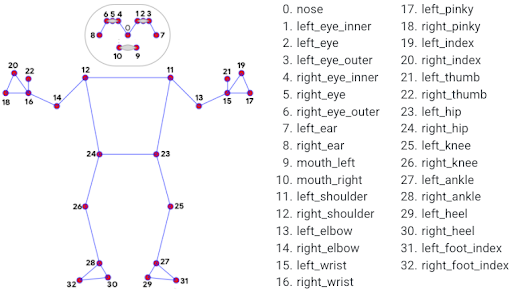

example_figure.png


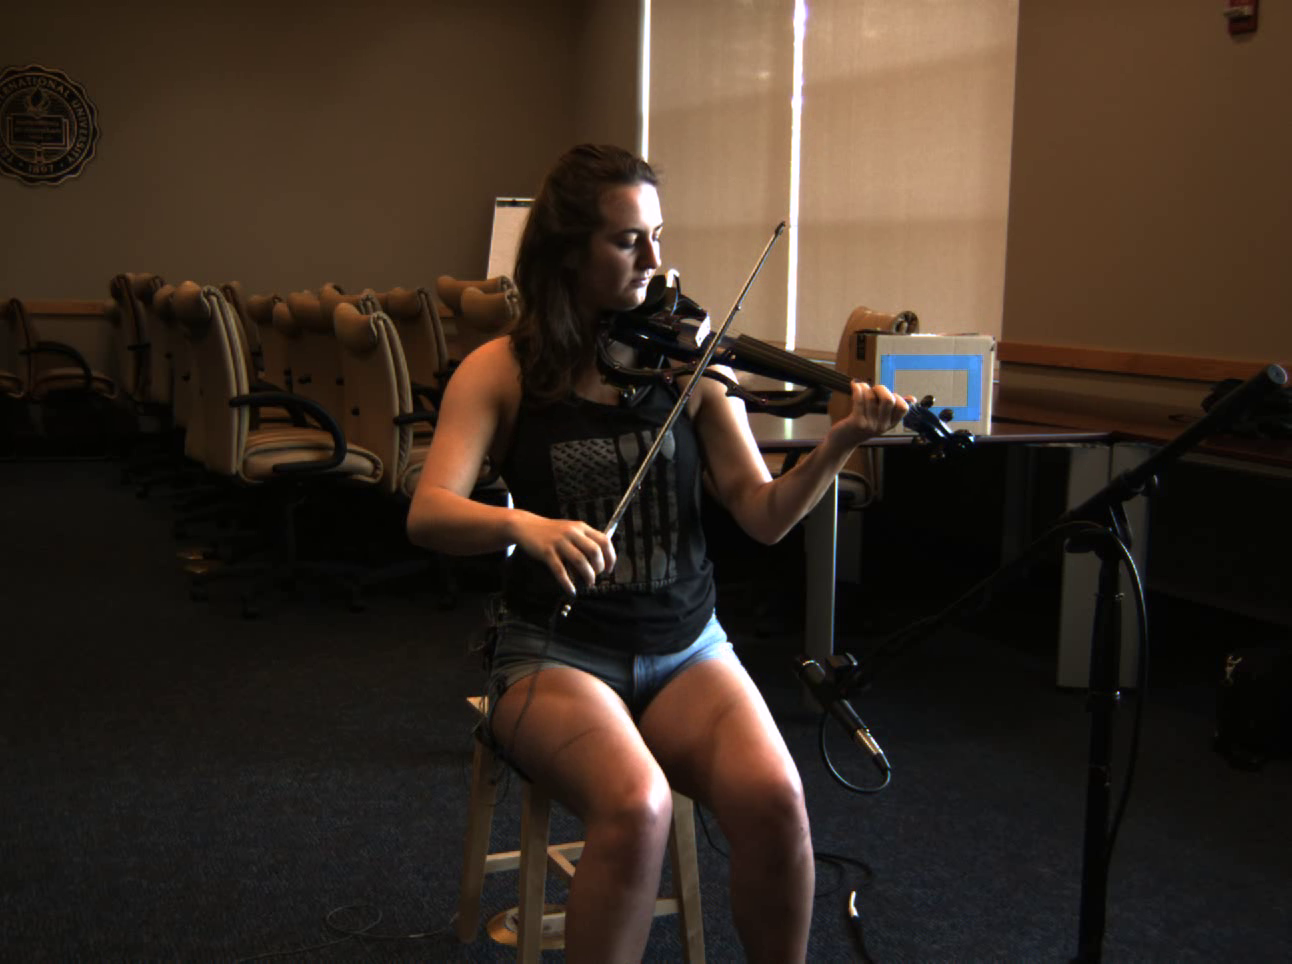

In [6]:
# Read images with OpenCV by uncommented the line you should use.
images = {name: cv2.imread(name) for name in uploaded.keys()}
#images = {'violin': cv2.imread('hyp_points.png')} #change the name of the image here!!!!!!!!!!!

# Preview the images.
for name, image in images.items():
  print(name)
  cv2_imshow(image)

In [7]:
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_tracking_confidence=0.5,
    output_segmentation_masks=False,
)
landmarker = vision.PoseLandmarker.create_from_options(options)

[example_figure.png] Nose coordinates: (650.0, 266.8)
Pose landmarks of example_figure.png:


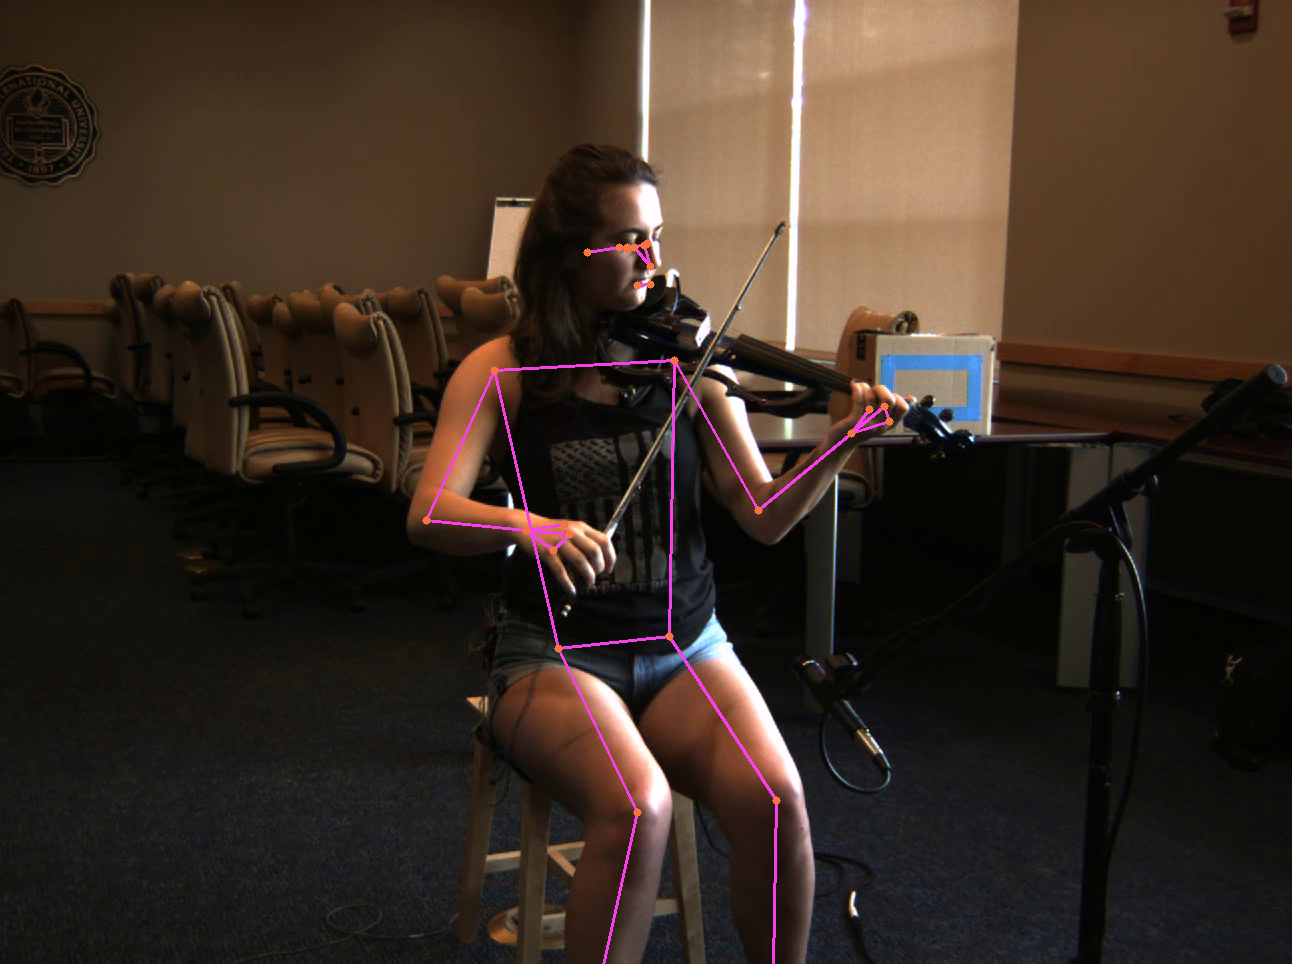

In [8]:
for name in uploaded:
    image_bgr = cv2.imread(name)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    result   = landmarker.detect(mp_image)

    if result.pose_landmarks:
        h, w = image_bgr.shape[:2]
        nose = result.pose_landmarks[0][NOSE]
        print(f'[{name}] Nose coordinates: ({nose.x * w:.1f}, {nose.y * h:.1f})')

    annotated = draw_landmarks_on_image(image_rgb, result)
    print(f'Pose landmarks of {name}:')
    cv2_imshow(cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))


## Try different images and try to find an image where it is difficult to find the pose (occlusions , strange poses ...) and comment a bit the results!!

### Let's now analyze videos.

Upload a video: click the Files folder icon fileFolderIcon.jpg in the left-hand column to see the current files in your virtual Colab environment and upload the file you want to analyze or use your webcam.

##Function to calculate angles

Calculate angles between different points and think if they are reasonable or not. Save the angles in a list and plot them.

In [9]:
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = (np.arctan2(c[1]-b[1], c[0]-b[0])
             - np.arctan2(a[1]-b[1], a[0]-b[0]))
    angle = np.abs(radians * 180.0 / np.pi)
    if angle > 180.0:
        angle = 360 - angle
    return angle

In [19]:
cap    = cv2.VideoCapture('cam0#030.avi')
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS) or 30

out        = cv2.VideoWriter('output.mp4', cv2.VideoWriter_fourcc(*'DIVX'), fps, (width, height))
angles_tot = []

In [20]:
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image  = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
    result    = landmarker.detect(mp_image)

    if result.pose_landmarks:
        lm = result.pose_landmarks[0]

        hip      = [lm[RHIP].x,  lm[RHIP].y]
        shoulder = [lm[RSH].x,   lm[RSH].y]
        elbow    = [lm[RELB].x,  lm[RELB].y]

        angle = calculate_angle(hip, shoulder, elbow)
        angles_tot.append(angle)

        elbow_px = (int(lm[RELB].x * width), int(lm[RELB].y * height))
        cv2.putText(frame, f'{angle:.1f}', elbow_px,
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2, cv2.LINE_AA)

    annotated_bgr = cv2.cvtColor(draw_landmarks_on_image(frame_rgb, result),
                                  cv2.COLOR_RGB2BGR)
    out.write(annotated_bgr)

cap.release()
out.release()

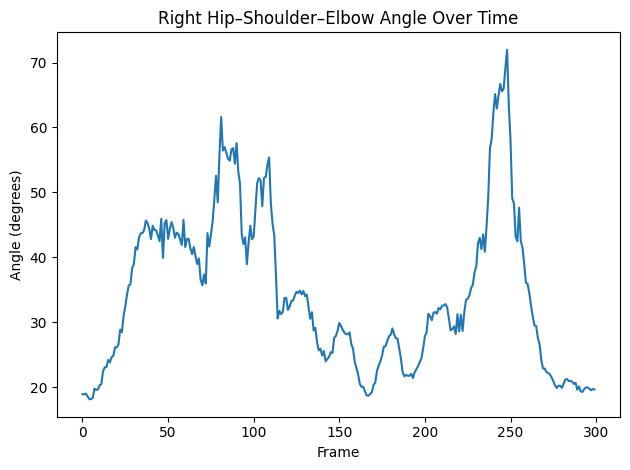

In [21]:
plt.figure()
plt.plot(angles_tot)
plt.xlabel('Frame')
plt.ylabel('Angle (degrees)')
plt.title('Right Hip–Shoulder–Elbow Angle Over Time')
plt.tight_layout()
plt.show()

##TODO
For instace it is possible to use the video of you walking or doing sport and try to compute the angle at the knee